## I koden nedan använder vi datasetet “housing.csv” som användes i kapitel 2.

In [12]:
print("hello")

hello


In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans

In [14]:
df = pd.read_csv("housing.csv")
X = df.loc[:, ["median_income", "latitude", "longitude"]]
print(X.head())
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
X["Cluster"] = kmeans.fit_predict(X)
X["Cluster"] = X["Cluster"].astype("category")

   median_income  latitude  longitude
0         8.3252     37.88    -122.23
1         8.3014     37.86    -122.22
2         7.2574     37.85    -122.24
3         5.6431     37.85    -122.25
4         3.8462     37.85    -122.25


   median_income  latitude  longitude Cluster
0         8.3252     37.88    -122.23       5
1         8.3014     37.86    -122.22       5
2         7.2574     37.85    -122.24       5
3         5.6431     37.85    -122.25       5
4         3.8462     37.85    -122.25       0


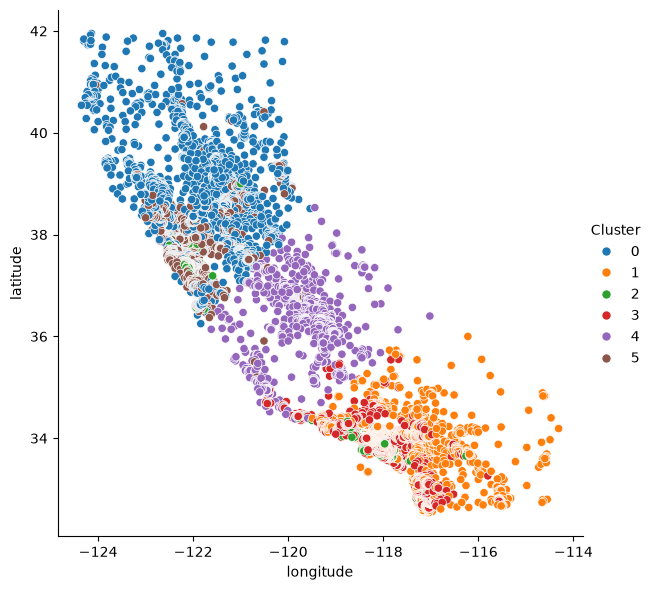

In [15]:
print(X.head())

sns.relplot( x="longitude", y="latitude", hue="Cluster", data=X, height=6,
)

### a) Förklara vad koden gör.

##### Koden läser in `housing.csv` och väljer medianinkomst samt geografiska koordinater som variabler. `KMeans` delar sedan in observationerna i sex kluster genom att placera varje bostad i det kluster vars centrum ligger närmast. Kolumnen `Cluster` innehåller klustertillhörigheten och görs om till en kategorisk variabel. I diagrammet visas longitud och latitud, medan färgen visar vilket kluster varje observation tillhör.

Jämförelse mellan modeller:


,antal_kluster,inertia,silhouette_score
0,2,101042.119,0.567
1,3,73393.534,0.503
2,4,56518.171,0.425
3,5,47169.087,0.375
4,6,39488.763,0.399
5,7,34708.148,0.364
6,8,30738.033,0.344
7,9,27664.481,0.348
8,10,25235.128,0.354


Bäst silhouette score: 2 kluster (0.567)


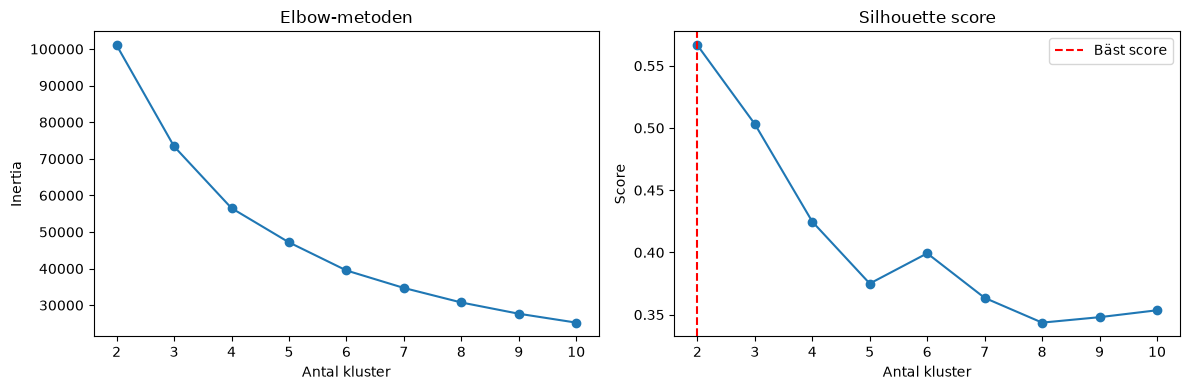

In [18]:
from sklearn.metrics import silhouette_score

# Vi testar flera möjliga antal kluster.
features = df[["median_income", "latitude", "longitude"]]
results = []

for cluster_count in range(2, 11):
    model = KMeans(n_clusters=cluster_count, random_state=42, n_init=10)
    labels = model.fit_predict(features)
    results.append({
        "antal_kluster": cluster_count,
        "inertia": model.inertia_,
        "silhouette_score": silhouette_score(features, labels)
    })

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df["silhouette_score"].idxmax()]

print("Jämförelse mellan modeller:")
display(results_df.round(3))
print(
    f"Bäst silhouette score: {best_row['antal_kluster']:.0f} kluster "
    f"({best_row['silhouette_score']:.3f})"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(results_df["antal_kluster"], results_df["inertia"], marker="o")
axes[0].set(
    title="Elbow-metoden",
    xlabel="Antal kluster",
    ylabel="Inertia"
)

axes[1].plot(
    results_df["antal_kluster"],
    results_df["silhouette_score"],
    marker="o"
)
axes[1].axvline(
    best_row["antal_kluster"],
    color="red",
    linestyle="--",
    label="Bäst score"
)
axes[1].set(
    title="Silhouette score",
    xlabel="Antal kluster",
    ylabel="Score"
)
axes[1].legend()
plt.tight_layout()
plt.show()

### b) I koden har vi sex kluster (0-5). I verkligheten hade man kunnat undersöka respektive kluster för att se vilka preferenser de har, t.ex. hur de föredrar att bli kontaktade, vilka hustyper de gillar och dylikt. Om du hade lett en undersökning, vilken information hade du velat ha om respektive kluster och hur hade du designat marknadsundersökningen?

##### Jag hade velat veta exempelvis hushållens storlek, ålder, livssituation, inkomst, budget, önskad hustyp, antal sovrum, pendlingsbehov, viktiga närområdesfaktorer och föredragen kontaktkanal. Jag hade först använt en kort webbenkät med både flervalsfrågor och några skalfrågor, till exempel hur viktiga pris, läge och skolor är på en skala från 1 till 5. Därefter hade jag kompletterat med några djupintervjuer från varje kluster. Urvalet bör vara tillräckligt stort och representativt, och frågorna bör testas på en liten pilotgrupp för att minska risken för ledande eller otydliga formuleringar.

### c) Det som tagits fram, hur kan det vara användbart i verkligheten för ett företag exempelvis?

##### Företaget kan använda klustren för att skapa mer relevanta målgrupper och anpassa marknadsföring, erbjudanden och säljinsatser. Ett kluster med hög medianinkomst kan exempelvis få information om större eller dyrare bostäder, medan ett annat kan få erbjudanden som fokuserar på pris, pendling eller närservice. Företaget kan också jämföra klustren geografiskt, planera var nya bostäder eller kampanjer bör riktas och följa hur kundgrupper förändras över tid. Klustren visar dock samband och målgrupper, inte säkra orsaker till kundernas beteenden.

### Tolkning av resultatet

##### I den här körningen är silhouette score högst för två kluster, vilket betyder att två grupper blir tydligast separerade enligt måttet. Elbow-kurvan planar samtidigt ut ungefär efter fyra till sex kluster. Jag skulle därför jämföra två, fyra och sex kluster med verksamhetens behov: två kluster är enklast att tolka, medan sex kluster kan ge mer detaljerade målgrupper. Innan ett slutligt val bör variablerna också skalas och resultatet kontrolleras så att medianinkomsten inte får oproportionerligt stor påverkan.

### d) Vi har gjort ett enkelt kodexempel, lek gärna runt och fortsätt utveckla det. Exempelvis kan du undersöka hur många kluster som vore bra att använda.

#### Silhouette score (0.567) visar att två kluster är det bästa valet enligt den statistiska utvärderingen. Elbow-metoden visar dock att fyra till sex kluster också kan vara rimligt. Om företaget vill ha enkla och tydliga målgrupper bör två kluster användas. Om företaget behöver mer detaljerad marknadsföring kan sex kluster vara mer användbart, även om de är något mindre tydligt separerade.